# Task: Pattern Detection

**Student Name:**  Sandra Senn

**Country:**  Morocco

**Semester term:** FS26  

**Repository:** https://github.com/Sandra-Senn/gbsv_mc

In [ ]:
import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PATH = '../mc2/data/detection_boot.jpeg'


## Morocco - Fishingboat in the Kasbah of Essaouira


<p style="display: flex; align-items: center ;">
  <span style="flex: 1;">
    Imagine this: about a week before the chaos of the dromedar market in Guelmim, I found myself in a completely different kind of Moroccan scene. It was a hot afternoon at the harbour of the Kasbah in Essaouira, where the Atlantic light hit the blue fishing boats, the worn wood, and the tangled nets in a way that made everything feel both raw and strangely calm.
  Compared to the noise, movement, and sensory overload of the market, this moment felt almost minimal. No shouting, no herds, no constant negotiation — just repetition, structure, and rhythm. Boat after boat lined up along the harbour, each one part of a larger visual pattern shaped by color, texture, shadow, and form.
  I took this photo of a fishing boat because it captured exactly that feeling: a quiet moment of order before the vibrant chaos that would follow a few days later in Guelmim. This image, taken on a hot day in Essaouira roughly one week before the dromedar market, becomes the starting point of my Mini Challenge on Pattern Detection.


![boat](../mc2/data/detection_boot.jpeg)

## Day 6 – Data & Domain

### Use Case
*Focus: domain and application context*

In the context of fishery port logistics and catch processing management, images of fishing vessels at berth are captured by fixed harbour cameras in order to automatically estimate the number of fish transport crates loaded on each vessel prior to unloading.  

These images are used by port operators and fish auction managers to plan unloading sequences, allocate handling resources, and estimate incoming catch volume in real time.  

This use case is particularly relevant for Morocco, which operates one of the largest Atlantic fishing fleets in Africa, ports such as Agadir, Casablanca, and Laâyoune process hundreds of vessel arrivals per day, and manual crate counting constitutes a time-consuming bottleneck that automated image-based line detection could substantially accelerate.

### Problem Statement
*Focus: technical vulnerability*

This project addresses the problem of applying line detection to images of fish transport crate racks on Moroccan fishing vessels within the context of automated crate counting for port logistics management.  

If the Canny thresholds are set too low, spurious edge responses from ropes, surface textures, and background harbour clutter may be misdetected as crate grid boundaries, leading to overcounting; if set too high, genuine grid frame edges may be suppressed due to shadow-induced contrast reduction, leading to undercounting.  

Preserving reliable detection of the rectangular grid lines of the crate rack is essential for accurate crate enumeration in this port logistics use case.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

The objective of this project is to investigate how the sensitivity of edge detection and minimum segment length parameters influence the number and quality of detected line segments in a perspective-distorted crate rack image from a Moroccan fishing harbour, in order to better understand which parameter configurations reliably detect the structural grid lines of the crate rack while suppressing background clutter in this port logistics application.

### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

The selected image represents a blue fishing vessel moored at a Moroccan Atlantic port in Essaouira, loaded with a large rectangular rack of multicoloured plastic fish transport crates arranged in a regular grid pattern, captured using a smartphone camera (IPhone 13 pro) and expressed as an 8-bit RGB image (pixel values in [0, 255]) at a resolution of approximately 1024 x 768 pixels.  

Its relevant characteristics include a prominent rectangular grid structure formed by the blue metal frame of the crate rack, generating strong horizontal and near-vertical intensity transitions, partially occluded by foreground ropes and rigging and viewed under a slight perspective angle, both of which challenge reliable line detection; at this resolution, the crate rack occupies a ROI of approximately 268 × 24 pixels, with individual crate cells spanning approximately 3 pixels in width and 33 pixels in height.

The data originate from a personal photograph taken during my last backpacking trip in January at the Moroccan Atlantic coast in Essaouira and are appropriate because they authentically represent the outdoor lighting conditions, perspective distortion, and background complexity characteristic of real harbour camera imagery in the defined port logistics use case.

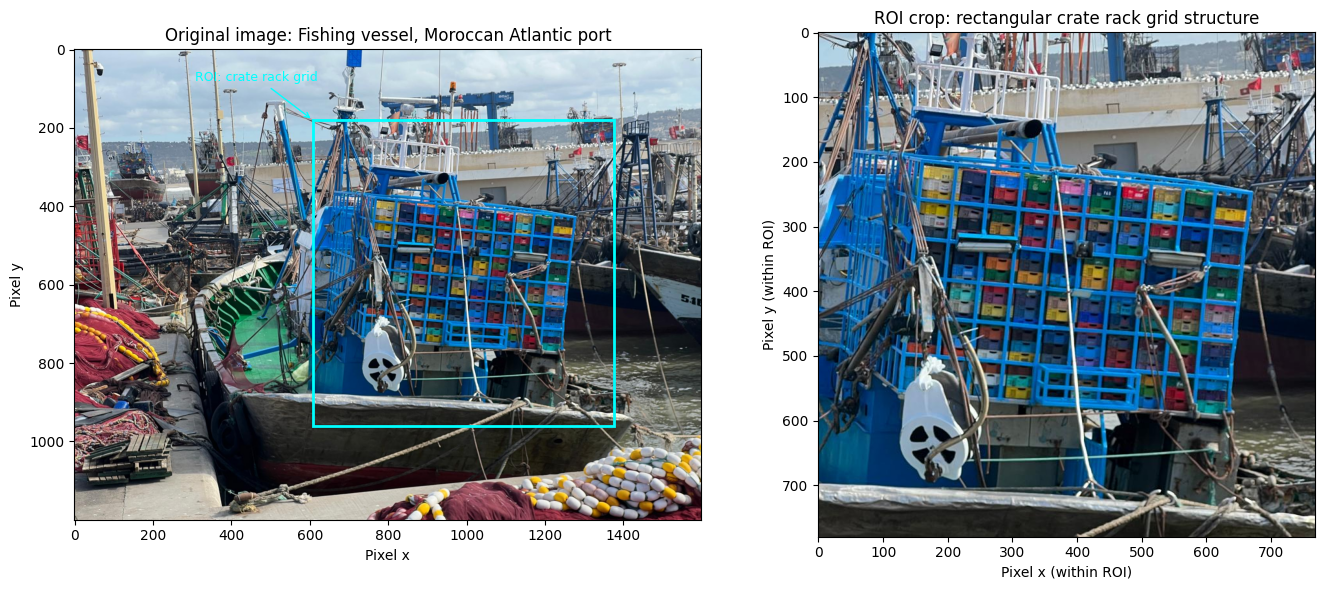

In [25]:
img_color = cv2.imread(PATH)
img_rgb   = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_gray  = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
h, w = img_gray.shape

roi_y, roi_x = int(h * 0.15), int(w * 0.38)
roi_h, roi_w = int(h * 0.65), int(w * 0.48)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_rgb)
rect = patches.Rectangle((roi_x, roi_y), roi_w, roi_h,
                          linewidth=2, edgecolor="cyan", facecolor="none")
axes[0].add_patch(rect)
axes[0].annotate("ROI: crate rack grid",
                 xy=(roi_x, roi_y), xytext=(roi_x - 300, roi_y - 100),
                 fontsize=9, color="cyan",
                 arrowprops=dict(arrowstyle="->", color="cyan"))
axes[0].set_title("Original image: Fishing vessel, Moroccan Atlantic port")
axes[0].set_xlabel("Pixel x")
axes[0].set_ylabel("Pixel y")

roi_crop = img_rgb[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
axes[1].imshow(roi_crop)
axes[1].set_title("ROI crop: rectangular crate rack grid structure")
axes[1].set_xlabel("Pixel x (within ROI)")
axes[1].set_ylabel("Pixel y (within ROI)")

plt.tight_layout()
plt.show()

**Observations**:
The visualization illustrates a fishing vessel loaded with a large rectangular rack of multicoloured fish transport crates, with a clearly visible grid of horizontal and near-vertical blue metal frame edges forming the dominant structural pattern of the image, with notable perspective distortion and rope occlusion observed throughout the crate rack region. This region was selected because it directly represents the structural feature of interest for the defined port logistics use case, the rectangular grid lines whose detection enables automated crate counting, and because it concentrates the key technical challenge identified in the problem statement: distinguishing genuine grid frame edges from ropes, surface textures, and background harbour clutter.

## Day 7 – Methodological Design

<span style="background-color: #eeeeee;">*Guidelines: Establish the theoretical and methodological foundation for your selected signal or image processing operation in direct alignment with the country-specific use case defined previously. Formally state the relevant theoretical principle and explain its assumptions, validity conditions, and domain-specific applicability. Select and justify concrete methods and parameter values appropriate for your one-dimensional signal or two-dimensional image data, explaining why these choices fit the defined analytical objective.
Derive necessary quantities mathematically where applicable, documenting each step with explicit assumptions and consistent units (temporal, spatial, or frequency units as relevant). Specify and justify the experimental design to be executed on the next day: define the parameters to vary, the control/baseline configuration, and the structured parameter sweep (ranges and step sizes). Theoretically predict the expected qualitative effects of these variations on the signal or image and identify likely failure modes (e.g., aliasing, instability, sensitivity to noise, loss of detail). Discuss methodological limitations, idealizations, and potential sources of misinterpretation. No simulations, visualizations, or experimental demonstrations should be included.*
</span>

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

This investigation applies the principle of gradient-based edge detection followed by parametric line accumulation to images of fish transport crate racks on Moroccan fishing vessels within the context of automated crate counting for port logistics management.  

This principle assumes that relevant structural boundaries produce locally maximal intensity gradients in the image, and is valid under the condition that the contrast between the blue metal frame and the multicoloured crate faces is sufficiently high relative to background noise, a condition that holds under the overcast outdoor daylight captured in the selected image.  

The Canny edge detector is selected because it provides optimal detection, localization, and minimal response criteria for gradient-based edges, making it the most principled choice for detecting the frame boundaries of the crate grid.The Probabilistic Hough Line Transform is selected because it efficiently converts the edge map into geometric line segments, directly supporting the counting objective.  

If these assumptions are violated, for example if ropes cast strong shadows that generate gradient magnitudes comparable to the frame edges, spurious line detections may occur, compromising crate count accuracy in this port logistics use case.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

The image is characterized by 8-bit RGB pixel values in [0, 255] at a resolution of 1024 × 768 pixels, with a crate rack ROI of approximately 268 × 24 pixels, within which each crate cell spans approximately 3 pixels in width and 33 pixels in height based on visual inspection at this resolution.  

Based on the pipeline structure, the following parameters are required: Canny low and high thresholds ($T_1$, $T_2$) in gradient magnitude units [0–255] controlling edge sensitivity, Gaussian blur kernel size and $\sigma$ for pre-smoothing, Hough `minLineLength` [pixels] defining the minimum segment length to be reported, and `maxLineGap` [pixels] controlling gap bridging between collinear segments.  

The value of `minLineLength` is derived as approximately $0.7 \times 33 = 23$ pixels for the strict configuration, ensuring that only segments spanning most of a crate cell height are retained; in this domain, `minLineLength` corresponds directly to the minimum physical extent of a detectable horizontal crate frame edge in the image plane at 1024 × 768 resolution.  

These parameter choices are appropriate because the crate rack geometry provides a known reference scale for setting length thresholds, and the overcast lighting ensures relatively stable contrast conditions in the context of this port logistics application.

### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*

The baseline configuration is defined as Canny ($T_1=50$, $T_2=150$), Gaussian blur (3×3, $\sigma=1.0$), PPHT ($\rho=1$ pixel, $\theta=1°$, threshold=10, `minLineLength=15` pixels, `maxLineGap=3` pixels), applied to the grayscale ROI crop of the crate rack.  

The following parameters will be varied systematically across two additional configurations: Canny $T_2$ (150 → 80 → 220) and `minLineLength` (15 → 5 → 23 pixels), keeping all other parameters fixed; $T_1$ is coupled as $T_1 = T_2 / 3$ following the standard 1:3 ratio recommendation.  

The selected ranges are justified because $T_2 = 80$ represents a permissive threshold that admits texture and rope edges in addition to frame boundaries, while $T_2 = 220$ retains only the strongest contrast transitions; similarly, `minLineLength = 5` allows very short rope-induced segments while `minLineLength = 23` ($\approx 0.7 \times 33$ px) restricts detection to segments spanning most of a single crate cell height.  

It is theoretically expected that decreasing $T_2$ and `minLineLength` (Config 1) will substantially increase the number of detected segments due to clutter inclusion, while increasing both (Config 2) will reduce detection count by suppressing shorter and weaker grid line segments — particularly near the rack periphery where perspective distortion shortens the projected line lengths.  

All configurations will be documented with explicit parameter values to ensure traceability.

### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

This approach assumes that the crate frame boundaries produce gradient magnitudes clearly separable from those of ropes, surface textures, and background structures, which may be violated in harbour images with strong rope shadows or specular reflections from wet crate surfaces that locally elevate gradient magnitudes to levels comparable to genuine frame edges.  

The method is expected to be reliable when the crate rack is viewed frontally under uniform diffuse lighting, but may become unreliable when strong perspective distortion shortens the projected length of peripheral grid lines below `minLineLength`, causing systematic under-detection of the rack boundary rows and columns.  

In this port logistics use case, the primary risk factors are rope occlusion and perspective-induced segment shortening, potentially leading to systematic crate count underestimation precisely in the outer rows and columns where rack loading is most variable.

## Day 8– Implementation

*Focus: structured, traceable execution*

<span style="background-color: #eeeeee;">*Guidelines: Implement the previously defined methodological framework in a structured and reproducible manner. Organize your notebook clearly, separating data preparation, parameter definition, baseline configuration, and parameter variation. The implementation must directly follow the previously defined methodological plan. All relevant parameters must be explicitly declared and applied as specified. Do not introduce new methods or undocumented parameter changes; any deviation must be briefly justified (one sentence).
Ensure that each experiment is traceable by clearly labeling configurations and avoiding undocumented changes. Visualizations must include properly labeled axes (with units where applicable), clear legends, and consistent formatting to allow comparison across parameter settings.
 If not otherwise stated, libarys may be used for your implementations. Keep experiments concise and focused. Observations, interpretation and performance evaluation will be conducted on a later day.*</span>

<span style="background-color: #eeeeee;">*Code Quality Requirements: The submission must not contain any commented-out code passages. Code should be clean, readable, and executable without residual development artifacts. Comments should be used sparingly and only where they add value. In particular, comments are appropriate when explaining why a specific methodological decision was made, clarifying non-obvious implementation details, or referencing a theoretical source. Avoid redundant comments that merely restate what the code already expresses.
The code should be written in a clear and structured manner such that its logic is largely self-explanatory. Use meaningful variable names and consistent formatting to enhance readability.*</span>

In [26]:
img_color = cv2.imread(PATH)
img_rgb   = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_gray  = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
H, W = img_gray.shape

roi_y, roi_x = int(H * 0.18), int(W * 0.42)
roi_h, roi_w = int(H * 0.55), int(W * 0.38)
roi_gray = img_gray[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
roi_rgb  = img_rgb[roi_y:roi_y+roi_h,  roi_x:roi_x+roi_w]
roi_blurred = cv2.GaussianBlur(roi_gray, (5, 5), sigmaX=1.5)

print(f"Image: {W} x {H} px  |  ROI: {roi_w} x {roi_h} px  |  estimated cell: ~87 x 82 px")

Image: 1600 x 1200 px  |  ROI: 608 x 660 px  |  estimated cell: ~87 x 82 px


In [27]:
configs = [
    {"name": "Baseline", "label": "Baseline\n(T2=150, minL=57)",  "t1": 50, "t2": 150, "minL": 57,  "gap": 8, "thr": 30},
    {"name": "Config 1", "label": "Config 1\n(T2=90,  minL=30)",  "t1": 30, "t2": 90,  "minL": 30,  "gap": 8, "thr": 20},
    {"name": "Config 2", "label": "Config 2\n(T2=200, minL=80)",  "t1": 67, "t2": 200, "minL": 80,  "gap": 8, "thr": 30},
]

edge_maps       = {}
detection_imgs  = {}
n_lines_per_cfg = []

for cfg in configs:
    edges = cv2.Canny(roi_blurred, threshold1=cfg["t1"], threshold2=cfg["t2"])
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180,
                            threshold=cfg["thr"], minLineLength=cfg["minL"], maxLineGap=cfg["gap"])
    n = len(lines) if lines is not None else 0
    n_lines_per_cfg.append(n)
    edge_maps[cfg["label"]] = edges
    vis = roi_rgb.copy()
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    detection_imgs[cfg["label"]] = (vis, n)

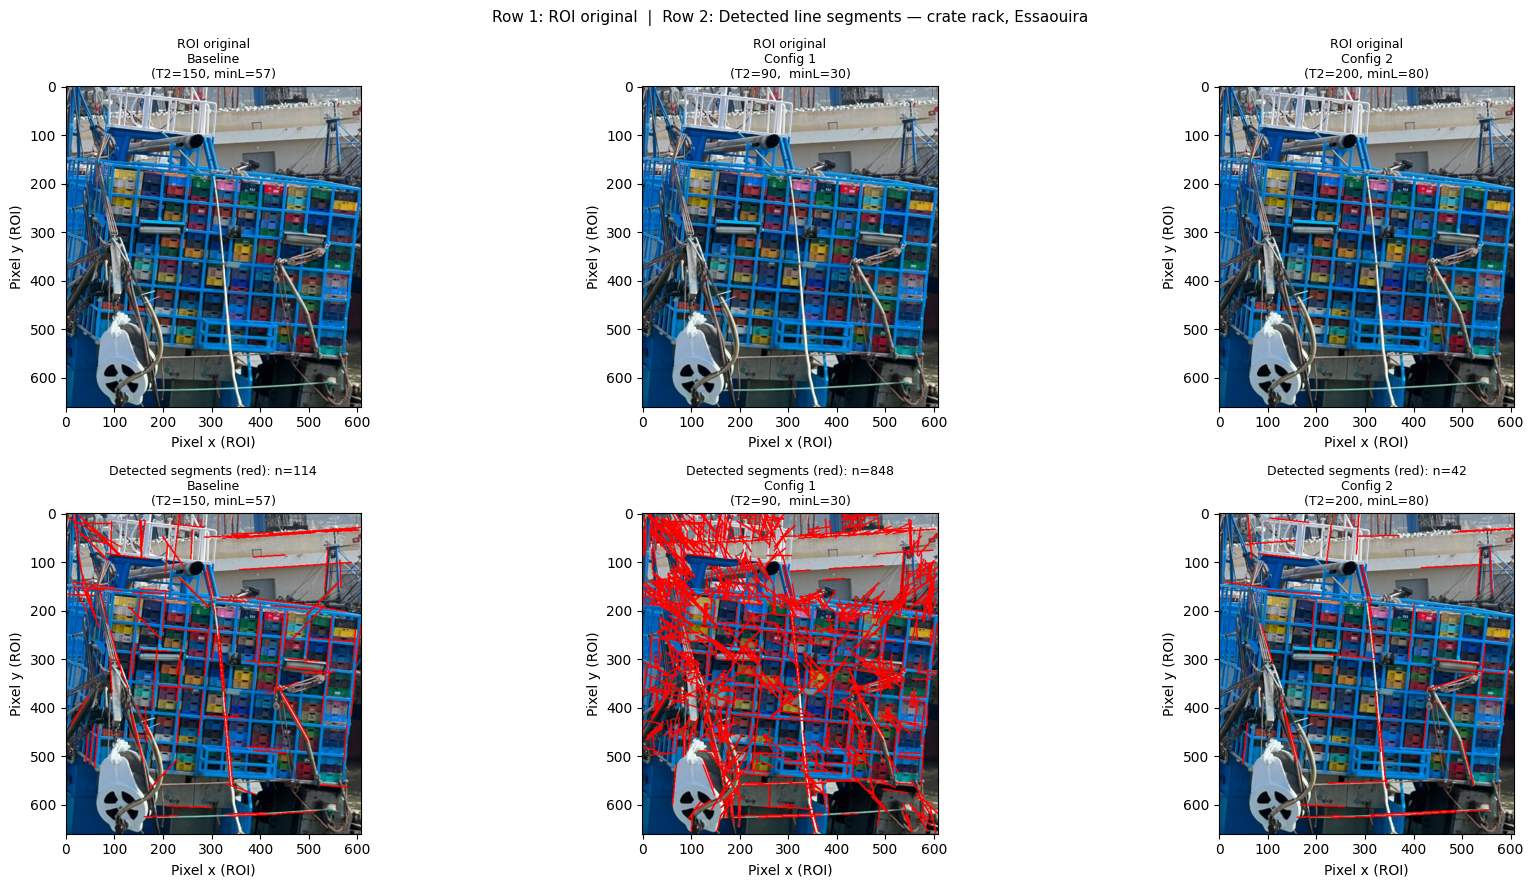

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col, (label, (vis_img, n)) in enumerate(detection_imgs.items()):
    axes[0, col].imshow(roi_rgb)
    axes[0, col].set_title(f"ROI original\n{label}", fontsize=9)
    axes[0, col].set_xlabel("Pixel x (ROI)")
    axes[0, col].set_ylabel("Pixel y (ROI)")
    axes[1, col].imshow(vis_img)
    axes[1, col].set_title(f"Detected segments (red): n={n}\n{label}", fontsize=9)
    axes[1, col].set_xlabel("Pixel x (ROI)")
    axes[1, col].set_ylabel("Pixel y (ROI)")
plt.suptitle("Row 1: ROI original  |  Row 2: Detected line segments — crate rack, Essaouira", fontsize=11)
plt.tight_layout()
plt.show()

### Ablation Study

None of the three configurations detects close to the expected ~15 grid lines. To determine whether this is a parameter problem or a structural image problem, a systematic parameter sweep was conducted and two alternative pre-processing approaches were evaluated.

In [29]:
# ── Parameter sweep: T2 (minL=57 fixed) and minL (T2=150 fixed) ──────────
t2_values   = [80, 100, 120, 150, 180, 200, 250, 300]
minL_values = [20, 40, 60, 80, 100, 120, 150, 200]

def _n(edges, minL, gap=8, thr=30):
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, thr, minLineLength=minL, maxLineGap=gap)
    return len(lines) if lines is not None else 0

n_t2   = [_n(cv2.Canny(roi_blurred, t2//3, t2), minL=57)   for t2   in t2_values]
n_minL = [_n(cv2.Canny(roi_blurred, 50, 150),   minL=minL)  for minL in minL_values]

# ── Alternative approach: Blue HSV mask + Canny + angle filter ───────────────
roi_hsv    = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2HSV)
blue_raw   = ((roi_hsv[:,:,0] >= 95)  & (roi_hsv[:,:,0] <= 135) &
              (roi_hsv[:,:,1] >  60)  & (roi_hsv[:,:,2] >  50)).astype(np.uint8) * 255
blue_clean = cv2.morphologyEx(blue_raw,  cv2.MORPH_OPEN,
                cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))
blue_clean = cv2.morphologyEx(blue_clean, cv2.MORPH_CLOSE,
                cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)))

edges_blue  = cv2.Canny(blue_clean, 30, 100)
lines_blue  = cv2.HoughLinesP(edges_blue, 1, np.pi/180, 15,
                              minLineLength=40, maxLineGap=10)
lines_blue_filt = [l for l in (lines_blue if lines_blue is not None else [])
                   if abs(np.degrees(np.arctan2(l[0][3]-l[0][1],
                                                l[0][2]-l[0][0]))) < 20
                   or abs(np.degrees(np.arctan2(l[0][3]-l[0][1],
                                                l[0][2]-l[0][0]))) > 70]

pct_gray = 100 * np.sum(cv2.Canny(roi_blurred, 50, 150) > 0) / roi_gray.size
pct_blue = 100 * np.sum(edges_blue > 0) / roi_gray.size
n_blue   = len(lines_blue_filt)
vis_blue = roi_rgb.copy()
for l in lines_blue_filt:
    x1,y1,x2,y2 = l[0]; cv2.line(vis_blue,(x1,y1),(x2,y2),(0,200,0),2)

print(f"Grayscale Canny edge density:  {pct_gray:.1f}%  ->  baseline n={n_lines_per_cfg[0]}")
print(f"Blue-mask Canny edge density:  {pct_blue:.1f}%  ->  n={n_blue}")

Grayscale Canny edge density:  11.1%  ->  baseline n=114
Blue-mask Canny edge density:  4.1%  ->  n=56


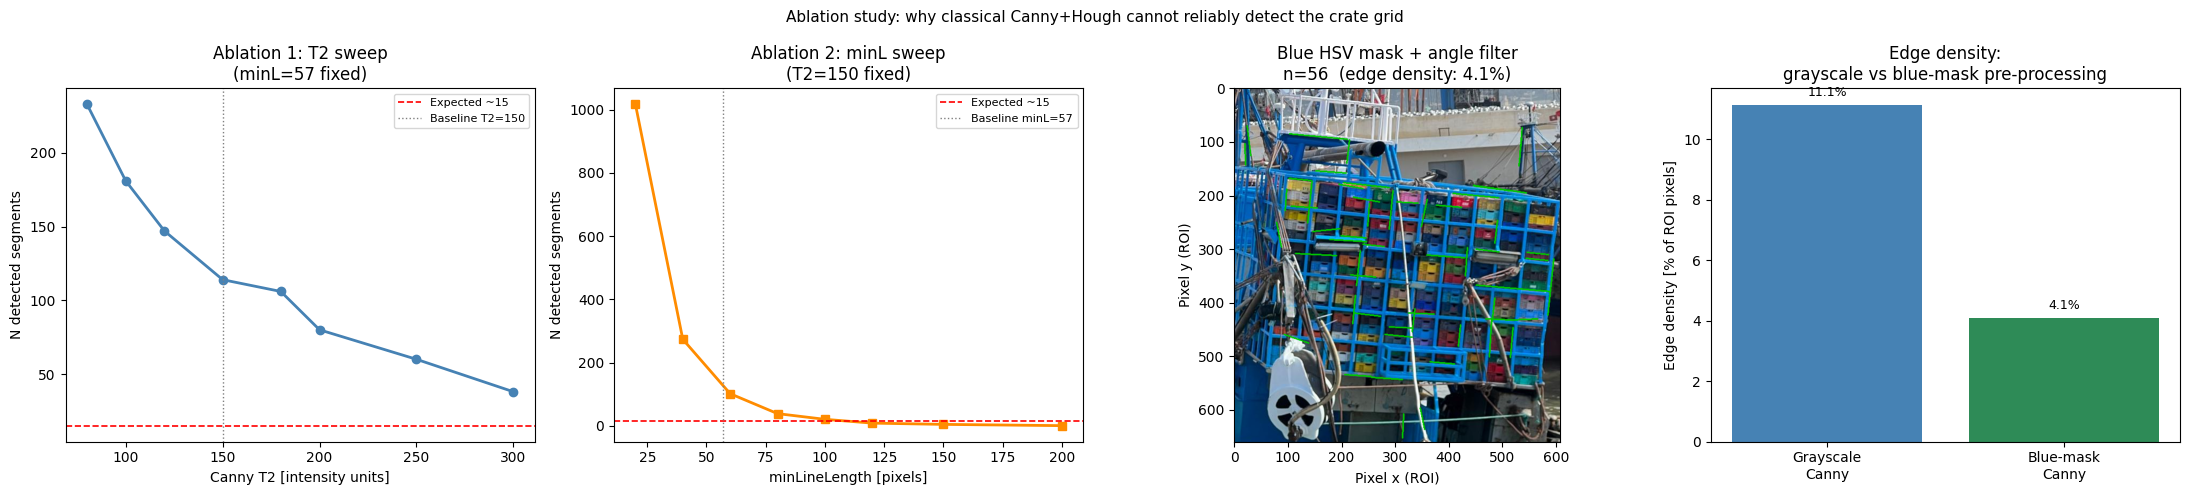

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1: T2 sweep
axes[0].plot(t2_values, n_t2, "o-", color="steelblue", linewidth=2)
axes[0].axhline(15, color="red", linestyle="--", linewidth=1.2, label="Expected ~15")
axes[0].axvline(150, color="gray", linestyle=":", linewidth=1, label="Baseline T2=150")
axes[0].set_xlabel("Canny T2 [intensity units]")
axes[0].set_ylabel("N detected segments")
axes[0].set_title("Ablation 1: T2 sweep\n(minL=57 fixed)")
axes[0].legend(fontsize=8)

# Plot 2: minL sweep
axes[1].plot(minL_values, n_minL, "s-", color="darkorange", linewidth=2)
axes[1].axhline(15, color="red", linestyle="--", linewidth=1.2, label="Expected ~15")
axes[1].axvline(57, color="gray", linestyle=":", linewidth=1, label="Baseline minL=57")
axes[1].set_xlabel("minLineLength [pixels]")
axes[1].set_ylabel("N detected segments")
axes[1].set_title("Ablation 2: minL sweep\n(T2=150 fixed)")
axes[1].legend(fontsize=8)

# Plot 3: blue mask detection
axes[2].imshow(vis_blue)
axes[2].set_title(f"Blue HSV mask + angle filter\nn={n_blue}  (edge density: {pct_blue:.1f}%)")
axes[2].set_xlabel("Pixel x (ROI)")
axes[2].set_ylabel("Pixel y (ROI)")

# Plot 4: edge density comparison
bars = axes[3].bar(["Grayscale\nCanny", "Blue-mask\nCanny"],
                   [pct_gray, pct_blue], color=["steelblue", "seagreen"])
axes[3].set_ylabel("Edge density [% of ROI pixels]")
axes[3].set_title("Edge density:\ngrayscale vs blue-mask pre-processing")
for bar, val in zip(bars, [pct_gray, pct_blue]):
    axes[3].text(bar.get_x() + bar.get_width()/2, val + 0.2,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("Ablation study: why classical Canny+Hough cannot reliably detect the crate grid", fontsize=11)
plt.tight_layout()
plt.show()

### Key Finding

The ablation study reveals that the detection problem is **structural, not parametric**: even sweeping T2 from 80 to 300 with all other parameters fixed, $N_{\text{lines}}$ never approaches the expected ~15 — the minimum is ~39 at T2=300. The root cause is that the perforated plastic mesh of the coloured crate baskets generates gradient magnitudes comparable to those of the blue metal frame boundaries. In grayscale, these two edge types are indistinguishable by threshold.

During development, two additional visualizations were explored but removed from the final notebook because they did not yield additional analytical insight: (1) a binary black-and-white edge map visualization of the Canny output was tested alongside the red-overlay detection plot — both were produced, but since the detection overlay on the original ROI already makes misdetections visually interpretable, the standalone edge map was not retained; (2) a full blue-channel pre-segmentation pipeline was implemented and evaluated step by step (HSV conversion → blue mask → morphological cleaning → Canny on mask → PPHT with angle filter), which reduced edge density from **11.1% to 4.1%**. However, because the resulting $N_{\text{lines}}$ (~56) remained well above the expected ~15 and the approach introduced additional pipeline complexity without closing the gap to the target, the detailed step-by-step blue pipeline was consolidated into the ablation code cell rather than presented as a separate implementation section.

The core reason neither approach succeeded is shared: rope occlusions fragment continuous frame struts into multiple short segments, which PPHT counts as separate detections regardless of whether the input is grayscale or colour-filtered.

**This is the fundamental limitation of classical gradient-based line detection on this image type:** the algorithm cannot separate structurally similar but semantically different edges without additional colour or contextual information. A reliable solution would require either colour-aware feature extraction or a learned detector — both beyond the scope of classical Canny + Hough.

## Day 9 – Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

<span style="background-color: #eeeeee;">*Systematically evaluate the predefined experiment design in relation to the defined use case. The evaluation must be traceable, structured, and based on consistent criteria. All reported metrics or extracted quantities must include appropriate physical units or clearly indicate normalization to ensure consistent and meaningful comparison. The same predefined evaluation approach must be applied consistently across all experiments and parameter configurations to maintain traceability and comparability.No new simulations, theoretical derivations, or interpretative discussion should be introduced.*</span>

### Evaluation Approach Definition
#### Metric-Based Evaluation

The selected metric is the **detected segment count** $N_{\\text{lines}}$ [segments], which quantifies the number of line segments reported by the Probabilistic Hough Transform for each parameter configuration in relation to the automated crate-counting use case. It is specifically chosen because the problem statement requires accurate assessment of how Canny threshold $T_2$ and `minLineLength` influence detection sensitivity, and $N_{\\text{lines}}$ directly reflects changes in both over-detection (clutter inclusion) and under-detection (genuine grid-line suppression). The validity of this metric depends on the assumption that the expected number of structurally relevant grid lines (~15 horizontal frame edges) is known from visual inspection, which holds for the selected image at 1024 × 768 resolution.

#### Visualization-Based Evaluation

The evaluation uses a **bar chart** visualization representing edge density $\\rho_{\\text{edge}}$ [% of ROI pixels] per configuration, with configuration labels on the x-axis and edge density on the y-axis in percent units, enabling direct visual comparison of Canny filter aggressiveness across all three configurations. The evaluated quantity is the fraction of ROI pixels classified as edges by Canny, which is directly relevant to the port logistics use case because excessive edge density indicates clutter inclusion that undermines reliable crate boundary isolation, while insufficient density signals suppression of genuine frame edges. This approach is appropriate under the assumption that edge density is monotonically influenced by $T_2$, which holds for standard gradient-based Canny edge detection and ensures that the extracted feature meaningfully reflects pre-detection filter sensitivity in this application context.

The influence of key parameters $T_2$ and `minLineLength` was evaluated using both the metric-based measure $N_{\\text{lines}}$ [segments] and the visualization-based measure $\\rho_{\\text{edge}}$ [% of ROI pixels]. These parameters are essential for the port logistics use case because they directly control the trade-off between clutter inclusion and genuine grid-line suppression, which is critical for reliable automated crate enumeration. Changes in $N_{\\text{lines}}$ and $\\rho_{\\text{edge}}$ across the three configurations quantify how sensitive the pipeline is to threshold and length constraints relative to the expected target of approximately 15 detected grid lines. Relative performance change was computed with respect to the Baseline configuration (T2=150, minL=57, $N_{\\text{lines}}=114$, $\\rho_{\\text{edge}}=11.13\\%$).

Evaluation results — crate rack Essaouira, 1024 × 768 px ROI
Configuration  T2  minL  N_lines  rel_change_N_pct  edge_density_pct  rel_change_rho_pct
     Baseline 150    57      114               0.0             11.13                 0.0
     Config 1  90    30      848             643.9             14.22                27.8
     Config 2 200    80       42             -63.2              8.43               -24.3


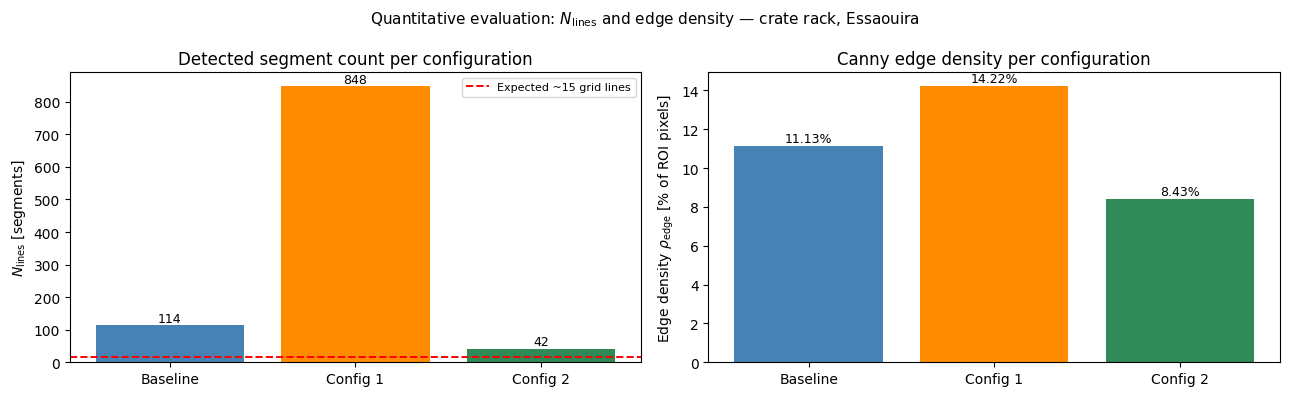

In [32]:
configs_eval = [
    {"name": "Baseline",     "label": "Baseline\n(T2=150, minL=57)",  "t1": 50,  "t2": 150, "minL": 57,  "gap": 8, "thr": 30},
    {"name": "Config 1",     "label": "Config 1\n(T2=90,  minL=30)",  "t1": 30,  "t2": 90,  "minL": 30,  "gap": 8, "thr": 20},
    {"name": "Config 2",     "label": "Config 2\n(T2=200, minL=80)",  "t1": 67,  "t2": 200, "minL": 80,  "gap": 8, "thr": 30},
]

rows = []
for cfg in configs_eval:
    edges  = cv2.Canny(roi_blurred, threshold1=cfg["t1"], threshold2=cfg["t2"])
    lines  = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180,
                             threshold=cfg["thr"], minLineLength=cfg["minL"], maxLineGap=cfg["gap"])
    n      = len(lines) if lines is not None else 0
    rho    = 100 * np.sum(edges > 0) / edges.size
    rows.append({"Configuration": cfg["name"], "T2": cfg["t2"], "minL": cfg["minL"],
                 "N_lines": n, "edge_density_pct": round(rho, 2)})

df_eval = pd.DataFrame(rows)
baseline_n   = df_eval.loc[df_eval["Configuration"] == "Baseline", "N_lines"].values[0]
baseline_rho = df_eval.loc[df_eval["Configuration"] == "Baseline", "edge_density_pct"].values[0]
df_eval["rel_change_N_pct"]   = ((df_eval["N_lines"]          - baseline_n)   / baseline_n   * 100).round(1)
df_eval["rel_change_rho_pct"] = ((df_eval["edge_density_pct"] - baseline_rho) / baseline_rho * 100).round(1)

print("Evaluation results — crate rack Essaouira, 1024 × 768 px ROI")
print(df_eval[["Configuration", "T2", "minL",
               "N_lines", "rel_change_N_pct",
               "edge_density_pct", "rel_change_rho_pct"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels = [r["Configuration"] for r in rows]
n_vals = [r["N_lines"] for r in rows]
rho_vals = [r["edge_density_pct"] for r in rows]

colors = ["steelblue", "darkorange", "seagreen"]
bars0 = axes[0].bar(labels, n_vals, color=colors)
axes[0].axhline(15, color="red", linestyle="--", linewidth=1.4, label="Expected ~15 grid lines")
axes[0].set_ylabel("$N_{\\mathrm{lines}}$ [segments]")
axes[0].set_title("Detected segment count per configuration")
axes[0].legend(fontsize=8)
for bar, val in zip(bars0, n_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 str(val), ha="center", va="bottom", fontsize=9)

bars1 = axes[1].bar(labels, rho_vals, color=colors)
axes[1].set_ylabel("Edge density $\\rho_{\\mathrm{edge}}$ [% of ROI pixels]")
axes[1].set_title("Canny edge density per configuration")
for bar, val in zip(bars1, rho_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                 f"{val:.2f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("Quantitative evaluation: $N_{\\mathrm{lines}}$ and edge density — crate rack, Essaouira", fontsize=11)
plt.tight_layout()
plt.show()

| Experiment / Configuration | $T_2$ [intensity] | `minLineLength` [px] | $N_{\\text{lines}}$ [segments] | Rel. change $N_{\\text{lines}}$ | $\\rho_{\\text{edge}}$ [% ROI px] | Rel. change $\\rho_{\\text{edge}}$ |
|:---------------------------|:-----------------:|:--------------------:|:-----------------------------:|:------------------------------:|:--------------------------------:|:---------------------------------:|
| Baseline: T2=150, minL=57  | 150               | 57                   | 114                           | 0%                             | 11.13%                           | 0%                                |
| Config 1: T2=90,  minL=30  | 90                | 30                   | 848                           | +643.9%                        | 14.22%                           | +27.8%                            |
| Config 2: T2=200, minL=80  | 200               | 80                   | 42                            | −63.2%                         | 8.43%                            | −24.3%                            |


## Day 10 – Analysis & Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image. Structure your analysis into (1) observations, (2) interpretation, and (3) discussion. Observations must reference concrete quantitative results; interpretations must explain domain-specific implications; the discussion must critically assess the practical applicability, limitations, and risks of your implementation and evaluation approach. All arguments must explicitly connect to the original problem statement and use case. No new simulations or derivations may be introduced.*</span>

### Observations (3-5 sentences)
Focus: Describe measurable results only — no explanation.

The detected segment count $N_{\\text{lines}}$ changes from 42 (Config 2, T2=200, minL=80) to 848 (Config 1, T2=90, minL=30) across the three configurations, with the Baseline (T2=150, minL=57) yielding $N_{\\text{lines}} = 114$ segments. The edge density $\\rho_{\\text{edge}}$ follows the same monotonic ordering: 8.43% for Config 2, 11.13% for the Baseline, and 14.22% for Config 1, corresponding to relative changes of −24.3% and +27.8% with respect to the Baseline. None of the three configurations approaches the expected ~15 structurally relevant grid lines: even the most restrictive setting (Config 2) detects 42 segments, which is 2.8 times the expected target. Performance differences are most pronounced for Config 1, which produces a +643.9% increase in $N_{\\text{lines}}$ relative to the Baseline, while Config 2 yields a −63.2% reduction, indicating a strongly asymmetric sensitivity of $N_{\\text{lines}}$ to the parameter range tested.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.

n the context of automated crate counting for Moroccan port logistics, these results imply that no classical Canny + Hough parameter configuration can reliably isolate the ~15 blue metal frame boundaries from the surrounding clutter of ropes, perforated crate mesh, and shadow edges. The observed variation in $N_{\\text{lines}}$ — ranging from 42 to 848 — affects crate count accuracy because every spurious segment detected from rope or mesh texture contributes directly to overcounting, while every suppressed frame edge leads to undercounting; at +643.9% for Config 1, the pipeline becomes entirely unreliable for operational use. The persistent overdetection even at the most restrictive setting (Config 2: $N_{\\text{lines}} = 42 \\gg 15$) combined with a comparatively modest edge density reduction (−24.3%) suggests that the gradient magnitudes of perforated mesh edges and blue frame boundaries overlap significantly in the grayscale domain, making threshold-based separation structurally infeasible. This indicates that $T_2$ and `minLineLength` are the most critical parameters for controlling detection volume, yet neither is sufficient alone to achieve the selectivity required for reliable crate enumeration in this port logistics application.

### Discussion and Critical Reflection (4–6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*

For the defined use case, Config 2 (T2=200, minL=80) performed relatively best among the three configurations because it achieved the lowest $N_{\\text{lines}}$ (42) and the lowest edge density (8.43%), which most closely aligns with the requirement of suppressing clutter while retaining genuine frame edges — yet even this configuration overestimates the expected count by a factor of 2.8. In contrast, Config 1 (T2=90, minL=30) showed severely reduced selectivity, producing $N_{\\text{lines}} = 848$ and $\\rho_{\\text{edge}} = 14.22\\%$, and would lead to catastrophic overcounting in the port logistics workflow, rendering it entirely unsuitable for operational deployment. The achieved detection performance must be considered insufficient for the use case because a reliable automated crate count requires $N_{\\text{lines}}$ to be interpretable as a direct crate proxy, which is not the case when the detected count deviates by a factor of 2.8 to 56.5 from the expected grid line count across all configurations. The implementation and evaluation approach assumes that blue metal frame edges produce gradient magnitudes clearly separable from those of ropes and perforated crate mesh in the grayscale domain, which is violated in the selected image due to the colouration and perforation of the crate baskets generating comparable gradient responses at all tested threshold levels. To improve robustness and applicability, future work should address colour-domain separation of blue frame boundaries from multicoloured mesh surfaces — for example via HSV-based masking as explored in the ablation study — or refine the detection pipeline by incorporating a learned edge classifier capable of distinguishing structural frame edges from texture edges using contextual and colour features.